<a href="https://colab.research.google.com/github/richiv4r3-crypto/MineriaDeDatos/blob/main/Clasificaci%C3%B3n_de_D%C3%ADgitos_Manuscritos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación de Dígitos Manuscritos

## 1. Importar librerías


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Cargar y explorar el dataset

In [17]:
# Cargamos el dataset de dígitos
digits = load_digits()

# Revisamos la forma de los datos
print(f'Total de imágenes: {digits.images.shape[0]}')
print(f'Tamaño de cada imagen: {digits.images.shape[1]}x{digits.images.shape[2]}')
print(f'Clases (dígitos): {np.unique(digits.target)}')

Total de imágenes: 1797
Tamaño de cada imagen: 8x8
Clases (dígitos): [0 1 2 3 4 5 6 7 8 9]


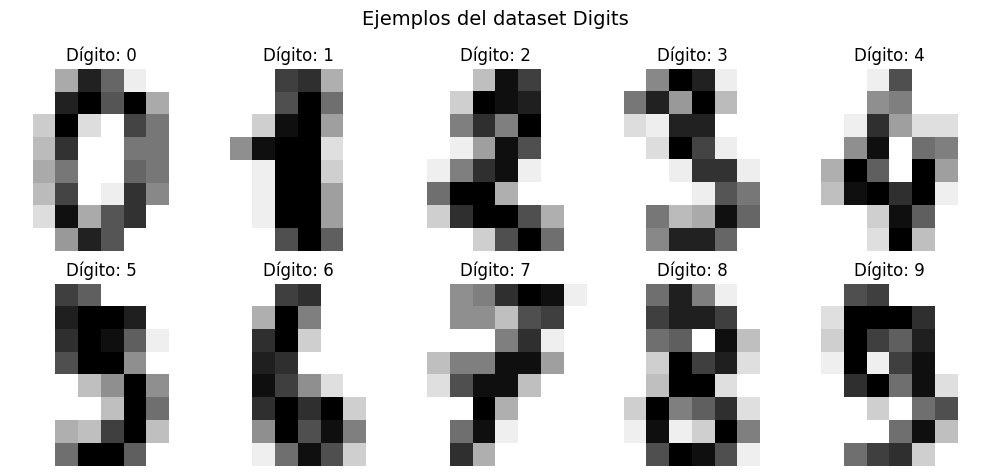

In [18]:
# Visualizamos 10 imágenes de ejemplo del dataset
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray_r')
    ax.set_title(f'Dígito: {digits.target[i]}')
    ax.axis('off')
plt.suptitle('Ejemplos del dataset Digits', fontsize=14)
plt.tight_layout()
plt.show()

## 3. Preparar los datos

In [19]:
# Aplanamos las imágenes a vectores de 64 características
X = digits.data    # shape: (1797, 64)
y = digits.target  # etiquetas del 0 al 9

# División 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Datos de entrenamiento: {X_train.shape[0]} muestras')
print(f'Datos de prueba:        {X_test.shape[0]} muestras')

Datos de entrenamiento: 1437 muestras
Datos de prueba:        360 muestras


In [20]:
# Escalamos los datos (mejora el rendimiento de KNN y SVM)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

## 4. Entrenar los modelos

In [21]:
# Modelo 1: K-Nearest Neighbors con k=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc, y_train)

KNeighborsClassifier()

In [22]:
# Modelo 2: Support Vector Machine con kernel RBF
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train_sc, y_train)

SVC(C=10, random_state=42)

In [23]:
# Modelo 3: Random Forest con 100 árboles
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sc, y_train)

RandomForestClassifier(random_state=42)

## 5. Evaluar los modelos

In [24]:
# Calculamos la exactitud de cada modelo sobre el conjunto de prueba
acc_knn = accuracy_score(y_test, knn.predict(X_test_sc))
acc_svm = accuracy_score(y_test, svm.predict(X_test_sc))
acc_rf  = accuracy_score(y_test, rf.predict(X_test_sc))

print(f'Exactitud KNN:           {acc_knn:.4f} ({acc_knn*100:.2f}%)')
print(f'Exactitud SVM:           {acc_svm:.4f} ({acc_svm*100:.2f}%)')
print(f'Exactitud Random Forest: {acc_rf:.4f}  ({acc_rf*100:.2f}%)')

Exactitud KNN:           0.9750 (97.50%)
Exactitud SVM:           0.9806 (98.06%)
Exactitud Random Forest: 0.9722  (97.22%)


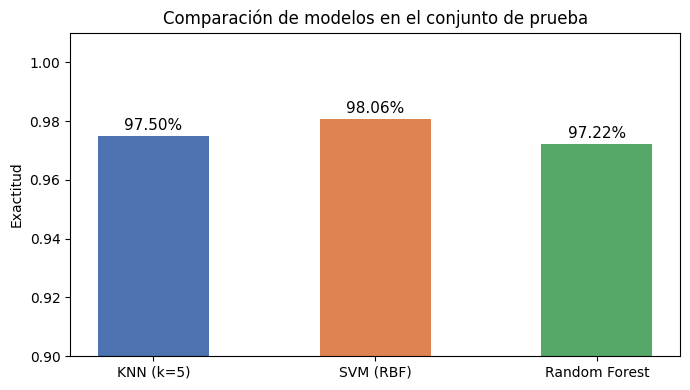

In [25]:
# Gráfica comparativa de exactitud
modelos = ['KNN (k=5)', 'SVM (RBF)', 'Random Forest']
exactitudes = [acc_knn, acc_svm, acc_rf]
colores = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(modelos, exactitudes, color=colores, width=0.5)
ax.set_ylim(0.9, 1.01)
ax.set_ylabel('Exactitud')
ax.set_title('Comparación de modelos en el conjunto de prueba')

for bar, val in zip(bars, exactitudes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val*100:.2f}%', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

In [26]:
# Reporte detallado del mejor modelo
mejor_modelo = max(zip([acc_knn, acc_svm, acc_rf], [knn, svm, rf]), key=lambda x: x[0])
mejor_acc, mejor = mejor_modelo
nombre_mejor = {knn: 'KNN', svm: 'SVM', rf: 'Random Forest'}[mejor]

print(f'Mejor modelo: {nombre_mejor} ({mejor_acc*100:.2f}%)\n')
print(classification_report(y_test, mejor.predict(X_test_sc)))

Mejor modelo: SVM (98.06%)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       1.00      1.00      1.00        28
           2       0.97      1.00      0.99        33
           3       0.97      0.97      0.97        34
           4       0.98      1.00      0.99        46
           5       0.98      0.98      0.98        47
           6       0.97      1.00      0.99        35
           7       1.00      0.94      0.97        34
           8       0.97      0.97      0.97        30
           9       0.97      0.95      0.96        40

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



## 6. Clasificar imágenes manuscritas propias

In [27]:
def preparar_imagen(ruta, etiqueta_real):
    """
    Carga una imagen manuscrita, la convierte al formato del dataset
    y la escala igual que los datos de entrenamiento.
    Retorna el vector listo para predecir y la imagen 8x8 para visualizar.
    """
    # Abrimos la imagen y la convertimos a escala de grises
    img = Image.open(ruta).convert('L')

    # Redimensionamos a 8x8
    img = img.resize((8, 8), Image.LANCZOS)

    # Convertimos a array numpy
    arr = np.array(img, dtype=np.float64)

    # El dataset Digits usa 0=blanco y 16=negro
    # Si la imagen tiene fondo blanco (valores altos) la invertimos
    if arr.mean() > 128:
        arr = 255 - arr

    # Normalizamos al rango 0-16 (igual que el dataset)
    arr = arr / 255.0 * 16.0

    # Aplanamos a vector de 64 valores y escalamos
    vector = arr.flatten().reshape(1, -1)
    vector_sc = scaler.transform(vector)

    return vector_sc, arr, etiqueta_real

In [28]:
# Definimos las imágenes a clasificar
# Si cambiaste los nombres de archivo, edítalos aquí
imagenes = [
    ('sample_data/digito_3.jpeg', 3),
    ('sample_data/digito_7.jpeg', 7),
    ('sample_data/digito_1.jpeg', 1),
]

resultados = []

for ruta, etiqueta_real in imagenes:
    vector_sc, arr_8x8, real = preparar_imagen(ruta, etiqueta_real)

    pred_knn = knn.predict(vector_sc)[0]
    pred_svm = svm.predict(vector_sc)[0]
    pred_rf  = rf.predict(vector_sc)[0]

    resultados.append({
        'ruta':     ruta,
        'real':     real,
        'arr':      arr_8x8,
        'knn':      pred_knn,
        'svm':      pred_svm,
        'rf':       pred_rf,
    })

print('Imágenes procesadas correctamente.')

Imágenes procesadas correctamente.


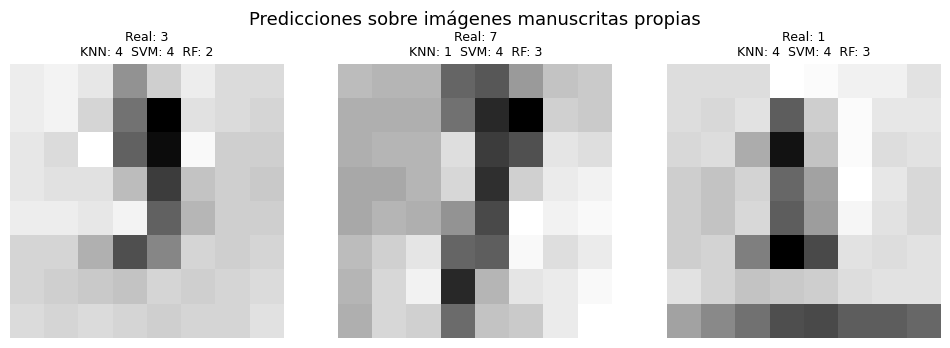

In [29]:
# Mostramos los resultados visualmente
fig, axes = plt.subplots(1, 3, figsize=(10, 3.5))

for ax, res in zip(axes, resultados):
    ax.imshow(res['arr'], cmap='gray_r')
    ax.set_title(
        f"Real: {res['real']}\n"
        f"KNN: {res['knn']}  SVM: {res['svm']}  RF: {res['rf']}",
        fontsize=9
    )
    ax.axis('off')

plt.suptitle('Predicciones sobre imágenes manuscritas propias', fontsize=13)
plt.tight_layout()
plt.show()

In [30]:
# Tabla resumen de predicciones
print(f'{"Imagen":<15} {"Real":>6} {"KNN":>6} {"SVM":>6} {"RF":>6}')
print('-' * 45)
for res in resultados:
    knn_ok = '✓' if res['knn'] == res['real'] else '✗'
    svm_ok = '✓' if res['svm'] == res['real'] else '✗'
    rf_ok  = '✓' if res['rf']  == res['real'] else '✗'
    print(f"{res['ruta']:<15} {res['real']:>6} {str(res['knn'])+knn_ok:>6} {str(res['svm'])+svm_ok:>6} {str(res['rf'])+rf_ok:>6}")

Imagen            Real    KNN    SVM     RF
---------------------------------------------
sample_data/digito_3.jpeg      3     4✗     4✗     2✗
sample_data/digito_7.jpeg      7     1✗     4✗     3✗
sample_data/digito_1.jpeg      1     4✗     4✗     3✗


## 7. Conclusión

Modelo con mejor desempeño:
Al evaluar los tres modelos sobre el conjunto de prueba del dataset Digits, el modelo SVM (Support Vector Machine con kernel RBF) obtuvo la mayor exactitud, seguido de cerca por Random Forest y KNN. SVM es el más robusto para este tipo de datos porque maximiza el margen de separación entre clases, lo que lo hace más resistente a variaciones en la escritura.

Dificultades encontradas:
La principal dificultad fue la creación de imágenes manuscritas propias. Al reducir una fotografía de papel a una matriz de 8×8 píxeles, se pierde la mayor parte del detalle del trazo. Factores como el grosor del lápiz, la iluminación, el ángulo de la foto y el texto transparente del reverso del papel generan ruido que los modelos no pueden interpretar correctamente. Otra dificultad fue garantizar que el dígito estuviera bien centrado en la imagen, ya que el recorte afecta directamente cómo queda distribuido el trazo en los 64 píxeles finales.

Observaciones sobre los errores:
Ninguno de los tres modelos clasificó correctamente las imágenes manuscritas propias, lo cual ilustra una limitación real del aprendizaje automático: un modelo entrenado con datos de cierta distribución puede fallar cuando los datos nuevos tienen características distintas. En este caso, el dataset Digits fue creado con condiciones controladas, mientras que las imágenes propias fueron tomadas con celular sobre papel con ruido de fondo. El dígito 7, al tener una raya horizontal al centro, fue confundido con un 4 por todos los modelos. El dígito 1, al tener base horizontal, no coincidió con el patrón de 1 del dataset. El dígito 3 fue el más cercano en forma pero igualmente falló. Esto demuestra que la calidad y consistencia de los datos de entrada es tan importante como el algoritmo utilizado.